<a href="https://colab.research.google.com/github/saraplattner/2025_Intro_Python/blob/main/Feedback_SaraPlattner_matplotlib_and_cartopy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feedback to Exercise W2_S2 (Replicating plots)

The exercise i found particularly challenging was the exercise from Week 2, Session 2. The exercise uses matplotlib and cartopy. The biggest challenges were issues with different projections. But there were also other smaller issues that made this exercise difficult for me. More details are in this feedback.

Every code window apart from the first one is supposed to run without errors.

## Exercise 1: Replicating Plots using `Matplotlib` and `Numpy`
The goal here is to **replicate** the figures you see **as closely as possible**.

These instructions in exercise 1 clearly say to replicate the figures exactly the way they are displayed. For part II this was not fully possible. Maybe it is possible, but in that case the exercise lacks some information on how to scale the colorbar in a way that it is exactly the same. Even to make it "almost exactly the same" was very hard because some important information is missing.

### Part I: Line and Contour Plots to Visualize Global Temperature Data


With the first part i did not have too many difficulties. But i have to say it felt a bit like a guessing game, which expression comes where. Especially the fact that the subplots (ax1 or ax2) have built-in methods for plotting for example the labels was new to me and did not come across enough in the lecture. In any other programming language that i ve come across so far (matlab and R), the labels and all these things are not methods of the subplot object. They are usually added afterwards/seperately.

Once i figured that out it was more or less easy.

One other thing i struggled with was the following line of code:

In [1]:
___._______(_____,ax=___,____='$^o$C')

AttributeError: 'str' object has no attribute '_______'

This line is the one that is creating the colorbar. However, the only hint i had, for knowing it should be the colorbar, was the label that should have shown "degrees Celsius". Being not very familiar with programming yet I did not recognise that these "complicated letters" should be the label for degree celsius. Once I found that out and i knew it must be the colorbar it was also more or less easy.

### Part II: Scatter Plots to Visualize Earthquake Data


With the part II of the first exercise I had a little more difficulties, but on the whole it still went well. The next field is just to be run so that the script works afterwards. The second field after this is the initial script I had. Run it to see how my plot looked like. Below I will explain what my problems were.

In [5]:
! pip install netCDF4

# We'll need to load the data from the UNIL sharepoint using pooch, so let's
# import the library
import pooch
import numpy as np
import matplotlib.pyplot as plt

fname = pooch.retrieve(
    "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EW1bnM3elHpAtjb1KtiEw0wB9Pl5w_FwrCvVRlnilXHCtg?download=1",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

# This is the function to the set the ticks in the colorbar to be in scientific notations.
# You can directly use this function and don't need to change anything in this cell.
import matplotlib.ticker as ticker
def fmt(x, pos):
    a, b = '{:.2e}'.format(x).split('e')
    b = int(b)
    return r'$10^{{{}}}$'.format(a)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.3 MB/s eta 0:00:00


Unzipping contents of '/root/.cache/pooch/64acbefd890a7bfdd423ac258fbaa5dc-EW1bnM3elHpAtjb1KtiEw0wB9Pl5w_FwrCvVRlnilXHCtg' to '/root/.cache/pooch/64acbefd890a7bfdd423ac258fbaa5dc-EW1bnM3elHpAtjb1KtiEw0wB9Pl5w_FwrCvVRlnilXHCtg.unzip'


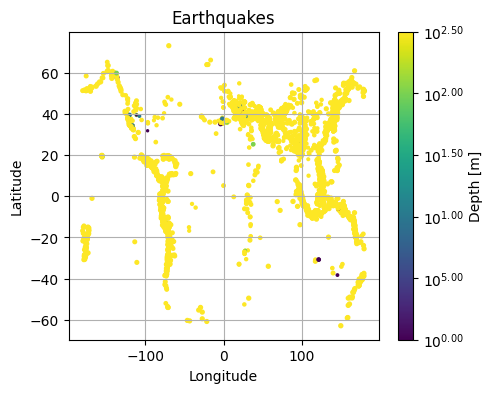

In [6]:
# Replicate the figure here
fig,ax3 = plt.subplots(1, 1, figsize=(5,4))
ctemp=ax3.scatter(longitude,latitude,s=magnitude,c=np.array(depth),marker='o',cmap='viridis',vmin=0,vmax=2.5)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth [m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')
plt.show()

As visible here, the vast majority of the data points is displayed yellow. The color should show the depth of the earthquake. And clearly not almost all the earthquakes have the same, very deep depth. So despite there being no error code, something must be wrong.
With the help of a TA i then figured out the following way to display the colors properly. The proper syntax was:

c = np.linspace(0,2.5,len(depth))

instead of:

c = np.array(depth)

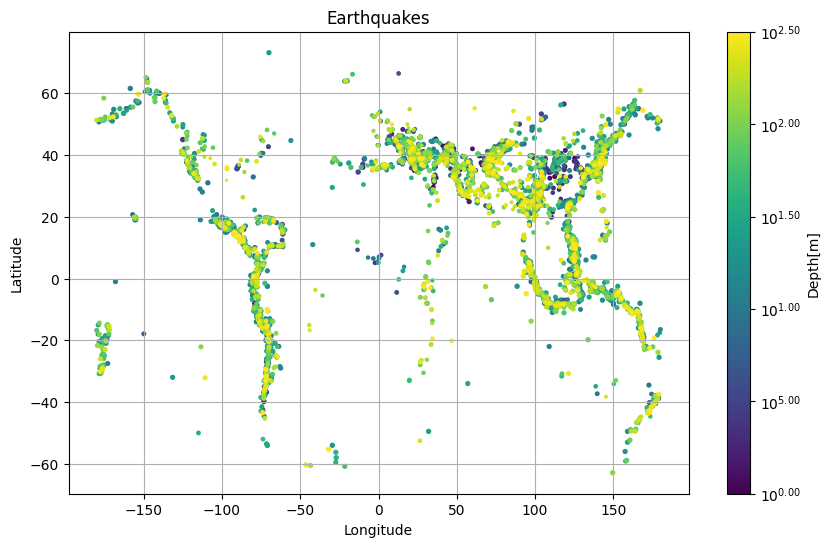

In [7]:
fig,ax3 = plt.subplots(1, 1, figsize=(10,6))
ctemp=ax3.scatter(longitude,latitude,s=magnitude, c=np.linspace(0,2.5,len(depth)),marker='o',cmap='viridis',vmin=0,vmax=2.5)

                  #c=np.array(depth),marker='o',cmap='viridis',vmin=0,vmax=2.5)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth[m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')

plt.show()

Having displayed this plot, I got quite confused, because simply from the information given in the expanation of the exercise I thought I must be done, but the plot still looked very different (i am mainly talking about the colors here!), so I assumed that I had done still something wrong.

When i asked, it was expained to me that the difference in appearance must be because the example plot was displaying the relative magnitude and my plot just the magnitude. However the magnitude sets the size of the points and my question was why the colors look off. I did adjust my plot to relative magnitude afterwards (surprise, the colors were still the same and looking off).

After a while of thoroughly inspecting both plots for hints, i found out that the example plot and my own plot do not show the same number of points. I realized this looking at the few points in the southeastern pacific. First i thought that we had recieved a different dataset than the one used in the example plot (which would have been not very nice, to confuse students with something like that), but luckily i found out it had another reason.

By  conincidence while exploring the two array options that make up colorscales (displayed above) I discovered that the dataset actually contains quite a big number of NaN values. Since i am not the most agile with Python, I went the complicated way and put everything in a DataFrame in order to get rid of the NaN values, because that is the library where I know how it works.

Then i made the following plot:





In [8]:
import pandas as pd

df = pd.DataFrame(earthquakes)
#df.head(20)

df2 = df.iloc[:, [8, 9, 20, 21]]
#df2.head(20)

df3 = df2.dropna()
#df3.head(20)

In [9]:
depth = df3[8]
magnitude = df3[9]
latitude = df3[20]
longitude = df3[21]

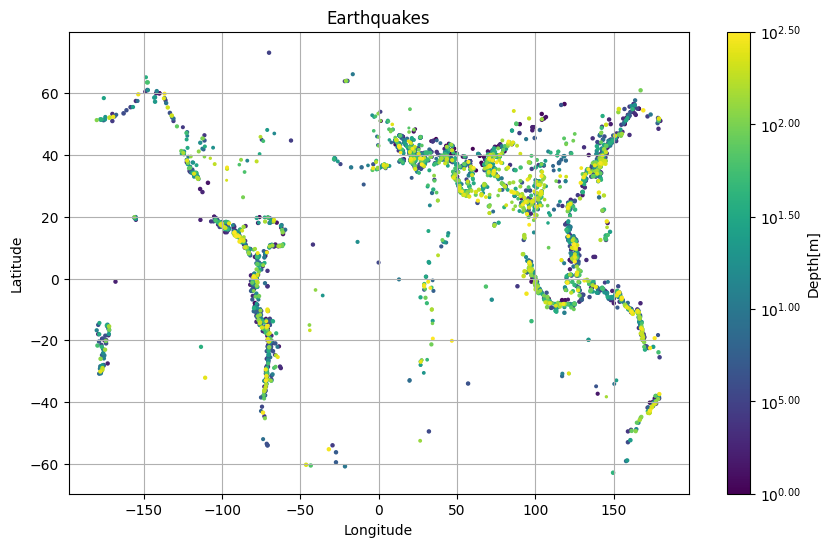

In [10]:
fig,ax3 = plt.subplots(1, 1, figsize=(10,6))
ctemp=ax3.scatter(longitude,latitude,s=magnitude/min(magnitude), c=np.linspace(0,2.5,len(depth)),marker='o',cmap='viridis',vmin=0,vmax=2.5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth[m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')

plt.show()

Now that the NaN values were all deleted, the plot looks much more similar to the example plot than the ones before. I also computed the relative magnitude, to make it look even more similar. Now there s only the color scale that still looks a bit odd. In the following plot I will try use logspace instead of linspace.

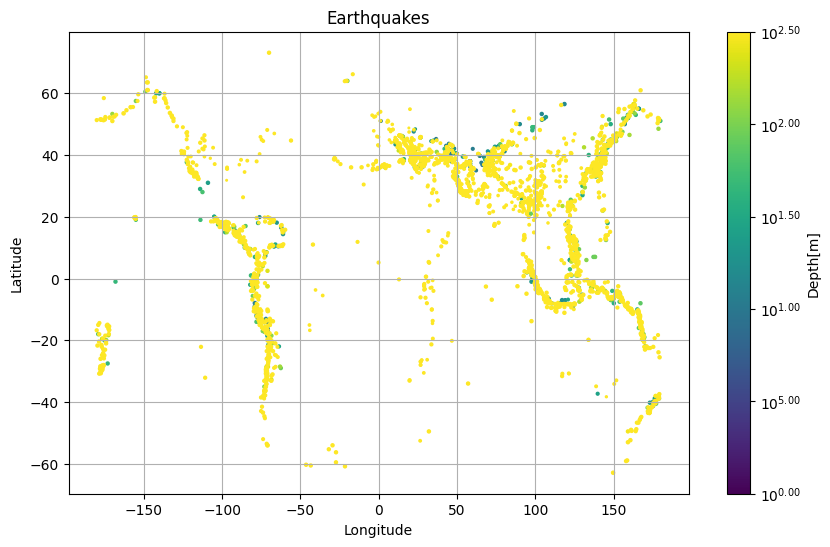

In [11]:
fig,ax3 = plt.subplots(1, 1, figsize=(10,6))
ctemp=ax3.scatter(longitude,latitude,s=magnitude/min(magnitude), c=np.logspace(0,2.5,len(depth)),marker='o',cmap='viridis',vmin=0,vmax=2.5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.grid()
fig.colorbar(ctemp,ax=ax3,label='Depth[m]',format=ticker.FuncFormatter(fmt))
ax3.set_title('Earthquakes')

plt.show()

This was clearly not a success. It looks again more like my first plot. I now ran out of ideas how to make the plot still look more similar to the example. I will call the plot before this one my final solution of this part of the exercise.

I want to add that maybe mentionning something in the explanation about dropping the NaN values would have been really helpful. It was more a coincidence that i discovered that it could be an issue of NaN values. I would have never found the solution by "just thinking about it" because since the points were still displayed on the plot I would not have assumed that they contain a NaN value. A little hint towards that would have been helpful and appreciated.

As a general feedback for this part of the exercise; for me it would have been really helpful if something like "consider that there might be NaN values" would have been mentionned in the explanation of the exercise. More hints about the colorscale would have been helpful too in order to replicate the plot **exactly** the same.

## Exercise 2: Cartopy


### Part I: Antarctic Sea Ice


I managed to solve this exercise after having help from both AI and comparing my script with the one from other students. I know now how the script needs to be to replicate exactly the same plot, but i do not know why. Some details do not make sense to me. I will show some error codes i had on the way and explain which details do not make sense.

again the next field is just to import a lot of stuff, in order to make the scripts work, that will be showed later

In [12]:
!pip install --no-binary 'shapely==1.6.4' 'shapely==1.6.4' --force
!pip install cartopy

import pooch
import cartopy
import cartopy.crs as ccrs
#import xarray as xr
from netCDF4 import Dataset
######################################################################################################################################################
# Download Sea Ice files
url1 = "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EREWA38Rs-FFslQd4yKZBAsBF8m9yLzeJKEAN5gSz7LLFw?download=1"
fname1 = pooch.retrieve(url1, known_hash='1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7')
url2 = "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/Ea_2umrDTkhCrN--th4nuokBMcnVlxGshiyUq2eSpvhlTQ?download=1"
fname2 = pooch.retrieve(url2, known_hash='309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66')
######################################################################################################################################################
# Run these as is. We are reading the sea ice concentration values from our files
seaice1,seaice2 = Dataset(fname1,'r'),Dataset(fname2,'r')
var_toplot1,var_toplot2 = seaice1.variables['seaice_conc_cdr'][:],seaice2.variables['seaice_conc_cdr'][:]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for shapely: filename=Shapely-1.6.4-py2.py3-none-any.whl size=155973 sha256=addc3ae92c2e843c01b64d51acc1a9a60fe05cdd47ba8d9a17e75cef941e11e6
  Stored in directory: /root/.cache/pip/wheels/04/48/f8/49eb7815e85eaf1ec42a8acdf38f1266b27eaedbcf527db25d
Successfully built shapely
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires shapely>=1.8.5, but you have shapely 1.6.4 which is incompatible.
geopandas 1.1.1 requires shapely>=2.0.0, but you have shapely 1.6.4 which is incompatible.
libpysal 4.13.0 requires shapely>=2.0.1, but you have shapely 1.6.4 which

The first thing that confused me already was the line *# the rest doesnt change* in the script. I never found out which rest, that never changes, was actually talked about.

A big problem for me with this exercise was, that for a long time i did not know what to put as an input in pcolormesh. I know it was written right above, but so far the instructions have never been written in the code itself but rather in the exercise explanations. So when coding i just always skipped the green comment part and tried about every possible way of getting a latitude and longitude in there without succeeding. The problem there was that i found no way to "view" my data before plotting it. I had no way to find out in which exact variable or which index the coordinates were stored. When i then realised that my missing information was right above i felt a bit stupid, but at least it almost worked then. I am aware that this problem is my own mistake and not necessarily a problem in the exercise. What might have helped in general is, to either always put instructions in text above the code or always put them in the code. Having a mixture of both is (at least to myself) rather confusing.

The code that got me almost the right solution is the following:

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


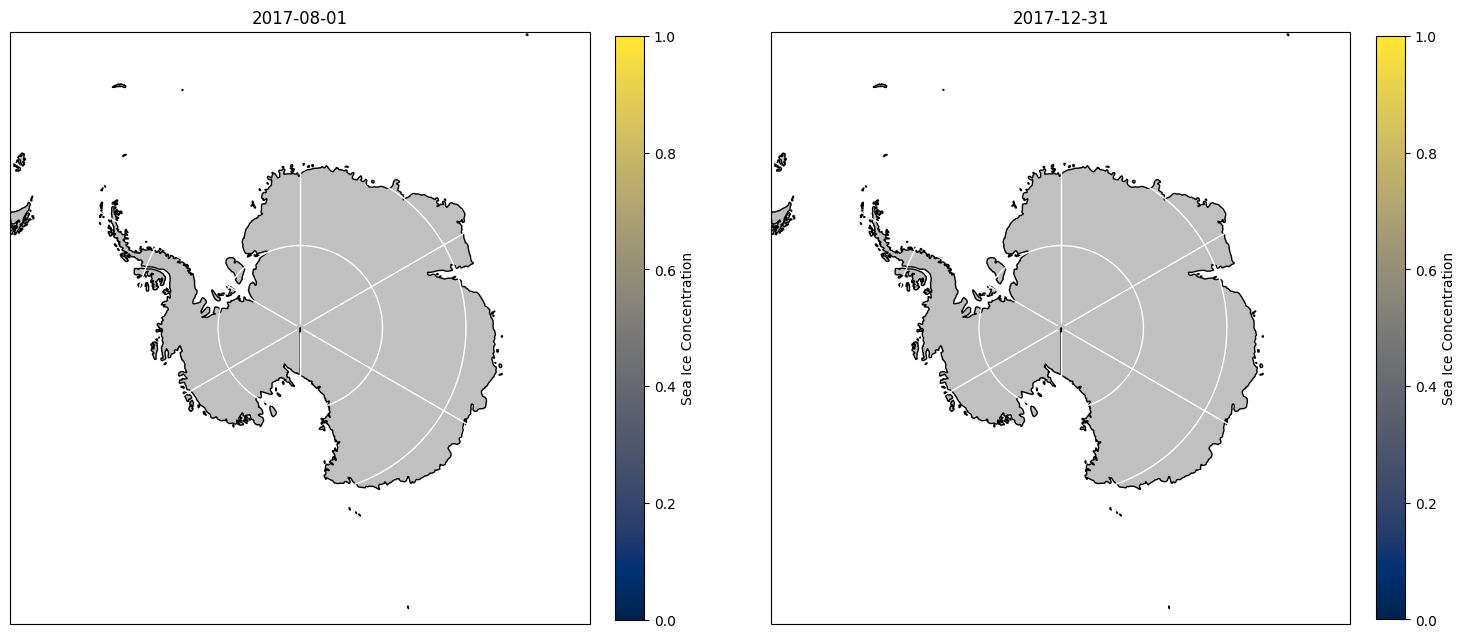

In [13]:
import matplotlib.pyplot as plt
#import cartopy.feature as cfeature
import numpy as np

fig,ax = plt.subplots(1,2,figsize=(18, 12),subplot_kw={'projection': ccrs.SouthPolarStereo()})
# The rest doesn't change:
ax[0].set_extent([-180, 180, -90, -55], ccrs.PlateCarree())

######################################################################################################################################################
# Add Land and gridlines
# Hint: Check edgecolor to show coast, and facecolor to color the continent
# Hint: https://matplotlib.org/stable/gallery/color/named_colors.html for the names of the colors available
######################################################################################################################################################
ax[0].add_feature(cartopy.feature.LAND, edgecolor='k',facecolor='silver')
ax[0].gridlines(lw=1,color='w')
######################################################################################################################################################
# Add Contours
# Hint: X (Y) data in the pcolormesh should be the longitude and latitude of the sea ice data.
# Hint: Check the shape of the var_toplot1, var_toplot2 before plotting
# Hint: longitude and latitude can be accessed with seaice1.variables['longitude'][:], seaice1.variables['latitude'][:]
# Hint: Check this website: https://matplotlib.org/stable/tutorials/colors/colormaps.html for available colormaps
######################################################################################################################################################
map0 = ax[0].pcolormesh(seaice1.variables['longitude'][:],
                        seaice1.variables['latitude'][:],
                        np.ma.masked_greater(var_toplot1[0,:,:],1),
                        transform=ccrs.epsg(3412),vmin=0,vmax=1,cmap='cividis')
plt.colorbar(map0,ax=ax[0],fraction=0.046, pad=0.04,label='Sea Ice Concentration')
ax[0].set_title('2017-08-01')


ax[1].set_extent([-180, 180, -90, -55], ccrs.PlateCarree())
ax[1].add_feature(cartopy.feature.LAND, edgecolor='k',facecolor='silver')
ax[1].gridlines(lw=1,color='w')

map1 = ax[1].pcolormesh(seaice2.variables['longitude'][:],
                        seaice2.variables['latitude'][:],
                        np.ma.masked_greater(var_toplot2[0,:,:],1),
                        transform=ccrs.epsg(3412),vmin=0,vmax=1,cmap='cividis')
plt.colorbar(map1,ax=ax[1],label='Sea Ice Concentration',fraction=0.046, pad=0.04)
ax[1].set_title('2017-12-31')
plt.show()

As clearly visible in the plots above, the land and everything is here, but the sea-ice data is not. I actually do not know why this script does not throw an error becasue when i tried to do the exercise it did not plot the land. It did do nothing and the error said something like "the dimensions of C (in pcolormesh) must be one smaller than 332 and 316". Unfortunately I cannot exactly replicate the error because now the same script somehow magically works or throws a different error. But my data had the dimensions (1,316,332), so i tried a lot of things to make them "shorter by one" or even to transpose the whole matrix because i thought that might be the problem. None of it worked.

However the problem was the projection. Another student told me in the end, that this is the problem, even though I do not fully understand why changing the projection changes the limits of what pcolormesh can plot. This is also the reason why in this plot here above (even though it does not throw an error) the sea ice does not show up because the wrong projection makes it appear in the wrong place. More specifically i had to change the projection in "transform" to PlateCarree in order for the script to work.

Now my issue with this whole problem is that in the exercise explanation we were specifically told to go explore the file contents to find out the projection. I did that and in the file contents I found the following line:

**projection: EPSG:3411, https://epsg.io/3412**

Apart from that there seems to be a Typo (because EPSG 3411 is NorthPoleStereographic) this line clearly seems to tell me that the data was taken in EPSG 3412 (so south steneographic). The way I learnt about transform in the lecture (and I checked again many times) is that "transform" requires the coordinate system of the input data in order to do the correct transformation.

To me it absolutely does not make sense why we then have to use PlateCarree for the "transform". But at least it worked afterwards after changing the projection. Here is the proof:

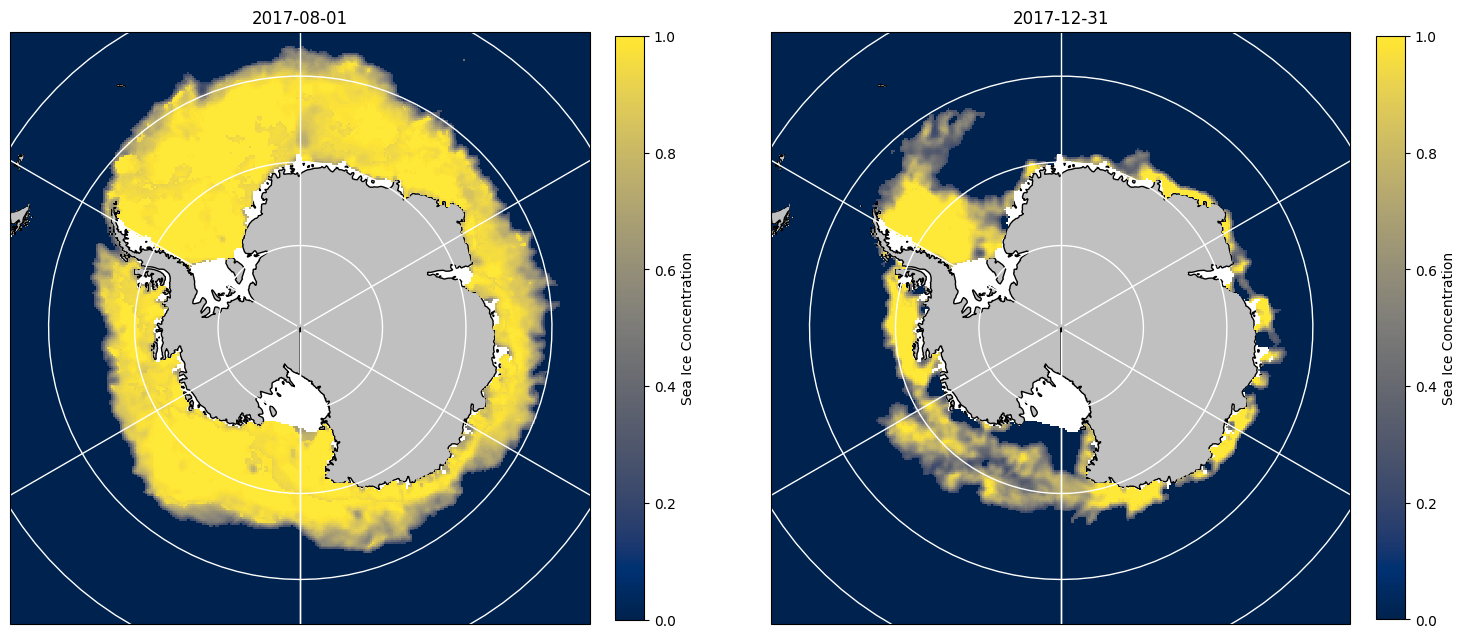

In [14]:
import matplotlib.pyplot as plt
#import cartopy.feature as cfeature
import numpy as np

fig,ax = plt.subplots(1,2,figsize=(18, 12),subplot_kw={'projection': ccrs.SouthPolarStereo()})
# The rest doesn't change:
ax[0].set_extent([-180, 180, -90, -55], ccrs.PlateCarree())

######################################################################################################################################################
# Add Land and gridlines
# Hint: Check edgecolor to show coast, and facecolor to color the continent
# Hint: https://matplotlib.org/stable/gallery/color/named_colors.html for the names of the colors available
######################################################################################################################################################
ax[0].add_feature(cartopy.feature.LAND, edgecolor='k',facecolor='silver')
ax[0].gridlines(lw=1,color='w')
######################################################################################################################################################
# Add Contours
# Hint: X (Y) data in the pcolormesh should be the longitude and latitude of the sea ice data.
# Hint: Check the shape of the var_toplot1, var_toplot2 before plotting
# Hint: longitude and latitude can be accessed with seaice1.variables['longitude'][:], seaice1.variables['latitude'][:]
# Hint: Check this website: https://matplotlib.org/stable/tutorials/colors/colormaps.html for available colormaps
######################################################################################################################################################
map0 = ax[0].pcolormesh(seaice1.variables['longitude'][:],
                        seaice1.variables['latitude'][:],
                        np.ma.masked_greater(var_toplot1[0,:,:],1),
                        transform=ccrs.PlateCarree(),vmin=0,vmax=1,cmap='cividis')
plt.colorbar(map0,ax=ax[0],fraction=0.046, pad=0.04,label='Sea Ice Concentration')
ax[0].set_title('2017-08-01')


ax[1].set_extent([-180, 180, -90, -55], ccrs.PlateCarree())
ax[1].add_feature(cartopy.feature.LAND, edgecolor='k',facecolor='silver')
ax[1].gridlines(lw=1,color='w')

map1 = ax[1].pcolormesh(seaice2.variables['longitude'][:],
                        seaice2.variables['latitude'][:],
                        np.ma.masked_greater(var_toplot2[0,:,:],1),
                        transform=ccrs.PlateCarree(),vmin=0,vmax=1,cmap='cividis')
plt.colorbar(map1,ax=ax[1],label='Sea Ice Concentration',fraction=0.046, pad=0.04)
ax[1].set_title('2017-12-31')
plt.show()

### Part II: 2014 Earthquakes


This last exercise was in general decently easy. By now i got used to how cartopy works and which ax and command is doing what. Since the first two projections were given and the first steps were only using the built-in methods add_feature that went well.

However, i did not manage to find the right projection for "transform" in order to make the earthquake points appear in the right place. I am aware that the exercise said again to explore the file contents for the right projection. But this time I did not find any way to display metadata. For the exercise before it was possible with the command print(seaice1) to view the metadata including the projection. Anyway, that was not successful for this exercise. I suppose that is the case because the two exercises have different data formats that they work with.
I tried some different projections to see if one would work. For exactly one projection the points showed up on the map. But completely in the wrong place. So i tried other projections again and unfortunately i cannot remember which projection made them at least show up.

My script is the second one to follow. The next is just for preparation so that the script works.

In [15]:
import pandas as pd
fname = pooch.retrieve(
    "https://unils-my.sharepoint.com/:x:/g/personal/tom_beucler_unil_ch/Ea9h1j2_wYpEtuX5waZZWpsBt2zh3lvGUBFisvA8dFG5Eg?download=1",
    known_hash='84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1')
usgs_2014 = pd.read_csv(fname)

######################################################################################################################################################
# Run these as is. We are removing missing values in the data and filter data points with stronger earthquakes (magnitude > 4)
usgs_2014_nonan = usgs_2014.dropna()
usgs_2014_large = usgs_2014_nonan[usgs_2014_nonan['mag']>4]

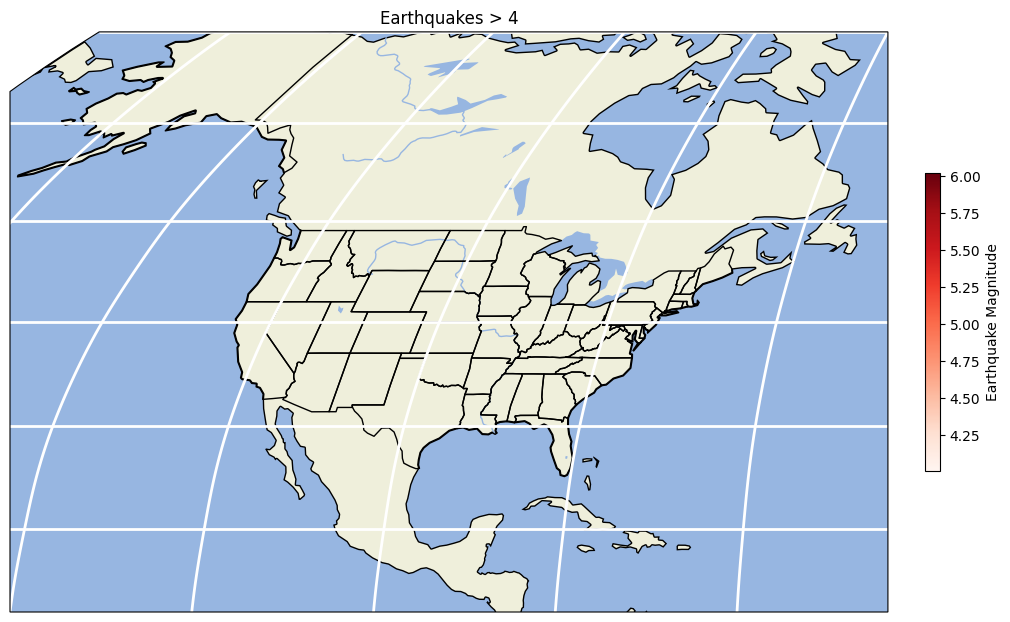

In [20]:
fig,ax = plt.subplots(1,1,figsize=(12, 12),subplot_kw={'projection': ccrs.Robinson()})
# The rest doesn't change:
ax.set_extent([-140, -60, 12,70], ccrs.PlateCarree())

######################################################################################################################################################
# Add Land, Ocean, Rivers, and State Lines
# Hint: Land linewidth = 3; States: edgecolor='gray',linewidth=1.25; lakes/ocean/rivers: no change
# Hint: https://matplotlib.org/stable/gallery/color/named_colors.html for the names of the colors available
######################################################################################################################################################
ax.add_feature(cartopy.feature.LAND, edgecolor='black',linewidths=2)
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.LAKES)
ax.add_feature(cartopy.feature.STATES,edgecolor='black',linewidth=1)
ax.gridlines(lw=2,color='white')

######################################################################################################################################################
# Add Scatter points for earthquake data
# Hint: usgs_2014_large['longitude'] to access logitude data, usgs_2014_large['latitude'] to access latitude data, usgs_2014_large['mag'] to access Earthquake magnitudes
# Hint: https://matplotlib.org/stable/gallery/color/named_colors.html for the names of the colors available
######################################################################################################################################################
c1 = ax.scatter(usgs_2014_large['latitude'],usgs_2014_large['longitude'],s=62,c=usgs_2014_large['mag'],marker='o',cmap='Reds',edgecolors='black',linewidths=2, transform=ccrs.PlateCarree())
plt.colorbar(c1,ax=ax,fraction=0.016, pad=0.04,label='Earthquake Magnitude')
ax.set_title('Earthquakes > 4')
plt.show()

After a long time of trying to debug my script i found my mistake. I put latitude on the x axis and longitude on the y axis. It should obviously be the other way around. The confusing thing about it was, that the data points did actually show up in one of the projections that I tried. Therefore I assumed it must be a problem of the projection.

I also assumed it must be a projection problem, because the exercise clearly asked to go check the projection of the data in the file contents. I could not find the file contents anywhere so i would have wished for a little more guiding on how to find the correct projection. Because had i known that my initial projection (PlateCarree) was correct, I would have looked for my bug somewhere else and maybe solved it a bit quicker.

And here is the proof that it worked afterwards:

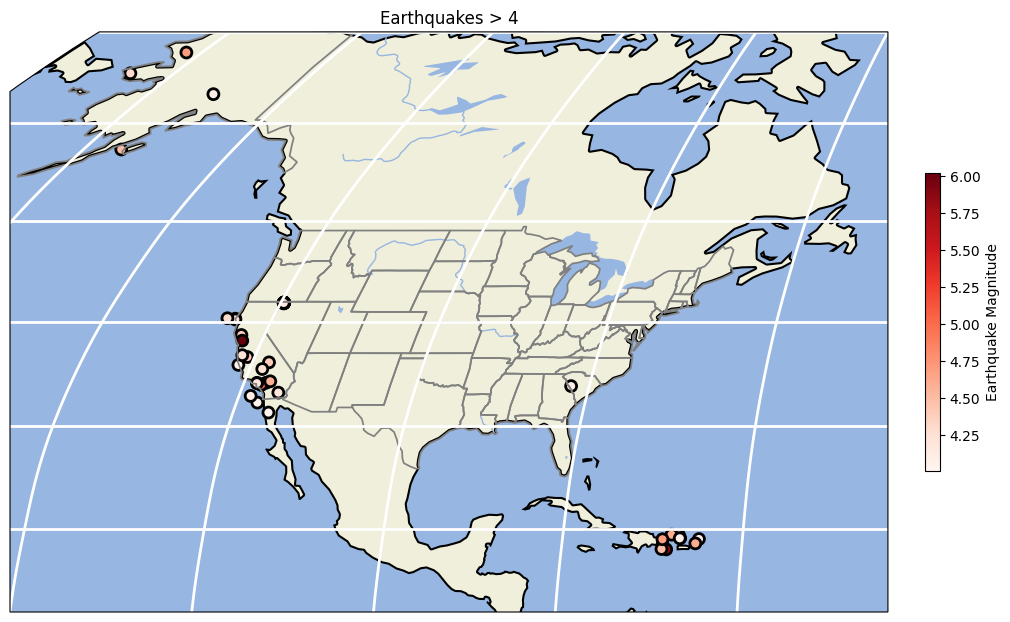

In [22]:
fig,ax = plt.subplots(1,1,figsize=(12, 12),subplot_kw={'projection': ccrs.Robinson()})
# The rest doesn't change:
ax.set_extent([-140, -60, 12,70], ccrs.PlateCarree())

######################################################################################################################################################
# Add Land, Ocean, Rivers, and State Lines
# Hint: Land linewidth = 3; States: edgecolor='gray',linewidth=1.25; lakes/ocean/rivers: no change
# Hint: https://matplotlib.org/stable/gallery/color/named_colors.html for the names of the colors available
######################################################################################################################################################
ax.add_feature(cartopy.feature.LAND, edgecolor='black',linewidths=3)
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.LAKES)
ax.add_feature(cartopy.feature.STATES,edgecolor='gray',linewidth=1.25)
ax.gridlines(lw=2,color='white')

######################################################################################################################################################
# Add Scatter points for earthquake data
# Hint: usgs_2014_large['longitude'] to access logitude data, usgs_2014_large['latitude'] to access latitude data, usgs_2014_large['mag'] to access Earthquake magnitudes
# Hint: https://matplotlib.org/stable/gallery/color/named_colors.html for the names of the colors available
######################################################################################################################################################
c1 = ax.scatter(usgs_2014_large['longitude'],usgs_2014_large['latitude'],s=62,c=usgs_2014_large['mag'],marker='o',cmap='Reds',edgecolors='black',linewidths=2, transform=ccrs.PlateCarree())
plt.colorbar(c1,ax=ax,fraction=0.016, pad=0.04,label='Earthquake Magnitude')
ax.set_title('Earthquakes > 4')
plt.show()

Looking back on it, this exercise was actually not too hard. With a bit more guidance on how to find the metadata i would call this a very good exercise.

On the whole I would say that all these exercises are good exercises to learn about matplotlib and cartopy. What would sometimes help is give a little more guidance on specific parts of the exercise that are hard for students to find out themselves (examples are mentionned in the text). To make it balanced between giving too much or too little guidance, there could be for example 3 exercises with a lot of guidance and then a 4th bonus exercise with almost no guidance. The bonus exercise should however then **not** cover new attributes/methods/etc. which have not been used before. The bonus exercise could be a repetition of the same things from the three exercises before, just with a different dataset, different map extents, different projections and color scalings.